<a href="https://colab.research.google.com/github/a-brhian/Design_Of_Experiments.pt/blob/main/03_Superficie_de_resposta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
#-------------------------------------------
# INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNOLOGIA DO AMAZONAS
#
# CREATED BY: SANDRA VIANA CÁD E ALYSSON BRHIAN
# DATA: 15/06/2012
# VERSION OF R: 4.6.0
#
# GOAL: Superfície de Resposta
# R.version.string
#---------------------------------------------

Esses são os pacotes que estão sendo utiliados neste código:

In [38]:
install.packages("rsm")
library(rsm)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



#Superfície de Resposta

O uso da Superfície de Resposta (_Response Surface Methodology – RSM_) é utilizada quando um experimento deseja analisar o impacto simultâneo de vários fatores quantitativos com o menor número possível de experimentos.

Para entender como e quando podemos usar essa metodologia, vamos analisar o problema a seguir.

##Introdução ao problema

Um engenheiro mecânico deseja minimizar a Rugosidade ($\mu$m) do acabamento de um eixo de aço AISI 1045. Ele escolheu dois fatores críticos no processo:

> Velocidade de corte ($V_c$), em (m/min); e

> Avanço ($f$), em mm/rot.

Os pontos centrais foram definidos como $V_c = 150 m/min$ e $f=0.15 mm/rot$. O $\alpha$ adotado foi de $\sqrt{2}$ para garantir a rotabilidade.

Vamos codificar os dados para evitar problemas de precisão numéricos, de acordo com o _script_ a seguir:

In [39]:
#Dados COM codificação
dados_mecanica <- data.frame(
  x1 = c(-1,  1, -1,  1,  0,  0,  0,  0,  0, -sqrt(2),  sqrt(2),  0,  0),
  x2 = c(-1, -1,  1,  1,  0,  0,  0,  0,  0,      0,      0, -sqrt(2), sqrt(2)),
  Rugosidade = c(1.25, 0.85, 2.45, 1.65, 0.95, 0.92, 0.98, 0.91, 0.94, 1.42, 0.78, 1.85, 2.95)
)

A equação que transforma o valor codificado para os valores reais são:

>Valor Real = Ponto Médio (Central) + Valor Codificado $\times$ Passo

Assim, temos as seguintes equações para as conversões de valores:

$
\left\{
\begin{aligned}
V_c^{\text{real}} &= 150 + (\text{Valor Codificado}) \times 30 \\
f^{\text{real}} &= 0.15 + (\text{Valor Codificado}) \times 0.05
\end{aligned}
\right.
$

A volta para os valores reais é feita com o _script_ abaixo:

In [40]:
#Dados SEM codificação
dados_mecanicaR <- data.frame(
  x1R = 150+dados_mecanica$x1*50,
  x2R = .15+dados_mecanica$x2*.05,
  Rugosidade = c(1.25, 0.85, 2.45, 1.65, 0.95, 0.92, 0.98, 0.91, 0.94, 1.42, 0.78, 1.85, 2.95)
)

head(data.frame(dados_mecanica,dados_mecanicaR))
tail(data.frame(dados_mecanica,dados_mecanicaR))

,x1,x2,Rugosidade,x1R,x2R,Rugosidade.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1,-1,1.25,100,0.10,1.25
2,1,-1,0.85,200,0.10,0.85
3,-1,1,2.45,100,0.20,2.45
4,1,1,1.65,200,0.20,1.65
5,0,0,0.95,150,0.15,0.95
6,0,0,0.92,150,0.15,0.92


,x1,x2,Rugosidade,x1R,x2R,Rugosidade.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8,0.000000,0.000000,0.91,150.00000,0.15000000,0.91
9,0.000000,0.000000,0.94,150.00000,0.15000000,0.94
10,-1.414214,0.000000,1.42,79.28932,0.15000000,1.42
11,1.414214,0.000000,0.78,220.71068,0.15000000,0.78
12,0.000000,-1.414214,1.85,150.00000,0.07928932,1.85
13,0.000000,1.414214,2.95,150.00000,0.22071068,2.95


## Visualização dos dados coletados

A visualização dos pontos do delineamento é feita por meio do seguinte _script_:

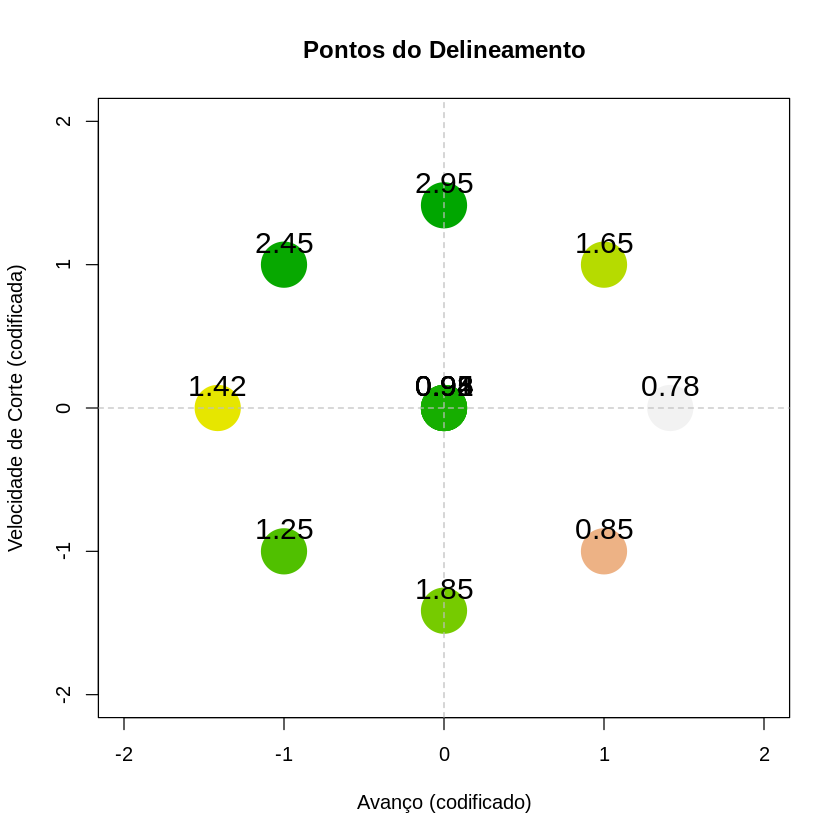

In [55]:
cores <- terrain.colors(50)

cor_pontos <- cores[
  cut(dados_mecanica$Rugosidade,
      breaks = 50,
      labels = FALSE)]

plot(dados_mecanica$x2,
     dados_mecanica$x1,
     pch = 19,
     cex = 5,
     ylim = c(-2,2),
     xlim = c(-2,2),
     ylab = "Velocidade de Corte (codificada)",
     xlab = "Avanço (codificado)",
     col = cor_pontos,
     main = "Pontos do Delineamento")

abline(h=0,v=0,lty=2,col="gray")

text(dados_mecanica$x1,
     dados_mecanica$x2,
     labels = round(dados_mecanica$Rugosidade, 2),
     pos = 3,
     cex = 1.5)

Com o gráfico acima, vemos que os dados indicam que os menores valores de rugosidade tendem para região de "média" velocidade de corte e "alto" avanço. O ponto central ficou com so valores de rugosidade distorcidos por conta da quantidade de amostras que foram sobrepostas.

Uma visualização em 3D desses dados seria por meio do seguinte _script_:

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



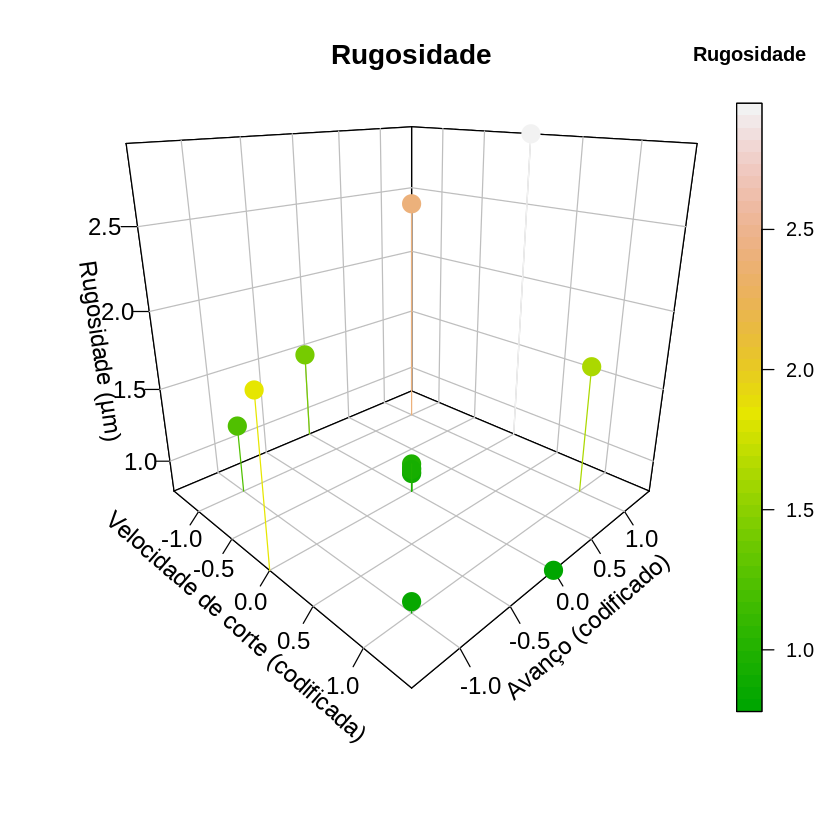

In [42]:
install.packages("plot3D")
library(plot3D)

scatter3D(
  x = dados_mecanica$x1,
  y = dados_mecanica$x2,
  z = dados_mecanica$Rugosidade,
  bty = "b2",

  # cor dos pontos
  colvar = dados_mecanica$Rugosidade,
  col = terrain.colors(50),

  # pontos
  pch = 19,
  cex = 2,

  # linhas até o plano xy
  type = "h",

  # ângulo de visualização
  theta = 45,
  phi = 20,

  # eixos
  xlab = "Velocidade de corte (codificada)",
  ylab = "Avanço (codificado)",
  zlab = "Rugosidade (µm)",

  # título
  main = "Rugosidade",

  # legenda
  clab = "Rugosidade",
  colkey = TRUE,

  # tamanhos
  cex.lab = 1.2,
  cex.axis = 1.2,
  cex.main = 1.4,

  ticktype = "detailed"
)

Esse gráfico em 3D confirma o que tínhamos observado anteriormente.

Uma outra visualização dos dados, não muito recomendado para esse problema, por haver regiões com uma amostra, é o _boxplot_, mas categorizado por regiões:

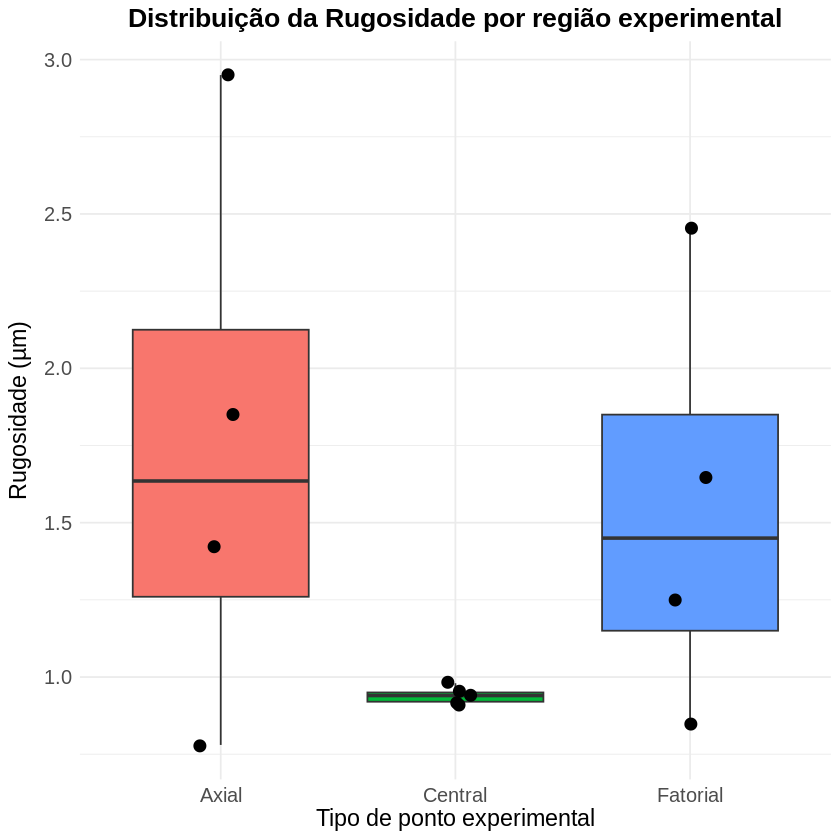

In [43]:
dados_mecanica$Tipo <- c(
  "Fatorial", "Fatorial", "Fatorial", "Fatorial",
  "Central", "Central", "Central", "Central", "Central",
  "Axial", "Axial", "Axial", "Axial"
)

library(ggplot2)

ggplot(dados_mecanica,
       aes(x = Tipo,
           y = Rugosidade,
           fill = Tipo)) +
  geom_boxplot() +
  geom_jitter(width = 0.1,
              size = 3) +
  labs(
    title = "Distribuição da Rugosidade por região experimental",
    x = "Tipo de ponto experimental",
    y = "Rugosidade (µm)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "none"
  )

O _boxplot_ acima mostra evidências de uma pequena dispersão, e um "baixo" valor nos valores da rugosidade para valores que se concentram na região "central" do experimento.

Futuramente precisaremos da função abaixo, pois pode ser usada para transformar um vetor de dados codificados para um vetor de dados reais, dado os parâmetros do ponto médio (`p.méd`) e do passo (`passo`):

In [44]:
cod2rea <- function(valor.cod, p.med, passo){
  #Converte valores codificados para real
  return(p.med+valor.cod*passo)
}

##O Modelo Teórico

Vamos ajustar os dados desse problema inicialmente a seguinte função:

$R_a=\beta_0+\beta_1V_c+\beta_2f+\beta_{12}V_c \times f+\beta_{11}V_c^2+\beta_{22}f^2+\epsilon$,

onde:

- $R_a$: Rugosidade prevista;
- $\beta_{0}$: Rugosidade média esperada no ponto central;
- $\beta_1,\beta_2$: Efeitos lineares da velocidade de corte e do avanço;
- $\beta_{12}$: Efeito da interação combinada da velocidade de corte e do avanço;
- $\beta_{11},\beta_{22}$: Termos quadráticos que definem a curvatura (parábola) de cada fator; e
- $\epsilon$: Erro experimental.

A estimação desses coeficientes é feita pelo seguinte _script_:

In [45]:
modelo_usinagem <- rsm(Rugosidade ~ SO(x1, x2), data = dados_mecanica)
summary(modelo_usinagem)


Call:
rsm(formula = Rugosidade ~ SO(x1, x2), data = dados_mecanica)

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept)  0.940000   0.058200 16.1512 8.483e-07 ***
x1          -0.263137   0.046011 -5.7190 0.0007211 ***
x2           0.444454   0.046011  9.6597 2.687e-05 ***
x1:x2       -0.100000   0.065070 -1.5368 0.1682210    
x1^2         0.030000   0.049341  0.6080 0.5623816    
x2^2         0.680000   0.049341 13.7815 2.499e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Multiple R-squared:  0.9786,	Adjusted R-squared:  0.9633 
F-statistic: 63.95 on 5 and 7 DF,  p-value: 1.089e-05

Analysis of Variance Table

Response: Rugosidade
            Df Sum Sq Mean Sq F value    Pr(>F)
FO(x1, x2)   2 2.1342 1.06712 63.0083 3.343e-05
TWI(x1, x2)  1 0.0400 0.04000  2.3618   0.16822
PQ(x1, x2)   2 3.2411 1.62054 95.6848 8.254e-06
Residuals    7 0.1186 0.01694                  
Lack of fit  3 0.1156 0.03852 51.3571   0.00119
Pure error   4 0.0030 0.000

É importante lembrar que os $\beta$s estimados estão em função das variáveis codificadas.

Além disso, `FO` (_Firt-Order_) representa os termos lineares, `TWI` (_Two-Way Interaction_) representa o termo de interação, e o `PQ` (_Pure Quadratic_) representa os termos quadráticos.

Na verdade, temos que testar as seguintes hipóteses quanto aos fatores:

> $H_0$: $\beta_i=0$ (o parâmetro de corte não afeta a rugosidade da peça); e

> $H_1$: $\beta_i\neq0$ (o parâmetro de corte afeta significativamente a rugosidade da peça).

E quanto a falta de ajuste (_Lack of Fit_):

> $H_0$: Não há falta de ajuste (o modelo matemático descreve perfeitamente o processo de usinagem); e

> $H_1$: Há falta de ajuste (a equação proposta não é a mais adequada).

Com os valores acima, podemos afirmar que ao nível de significância de $5\%$ a amostra apresenta evidências de que não existe interação entre as variáveis de velocidade de corte e avanço ($V_c\times f$), e que o termo quadrático da velocidade de corte ($V_c^2$) pode ser desprezado. Além disso, existem evidências de que o modelo ainda pode ser melhorado.

Fica para o leitor verificar se esse modelo e os próximos, passam nos pressupostos de uma ANOVA: normalidade, homocedasticidade e independência nos resíduos.

Antes, vamos ver como ficou graficamente o modelo ajustado:

$R_a=0.9400-0.2632V_c+0.4445f-0.1000V_c \times f+0.0299V_c^2+0.6801f^2$


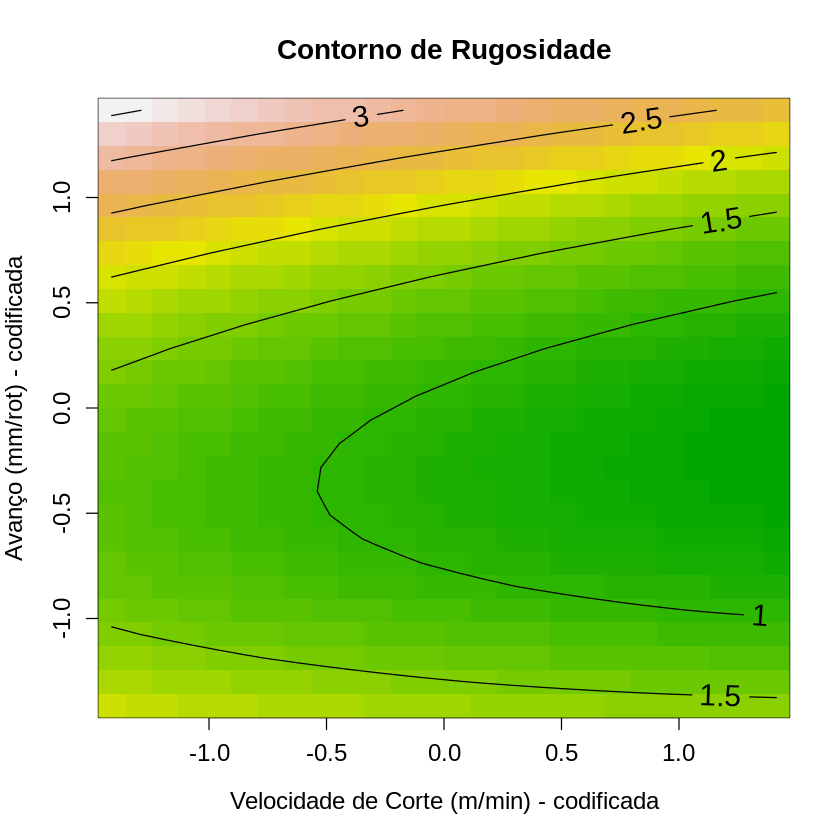

In [46]:
suppressWarnings(contour(modelo_usinagem, ~ x1 + x2,
        image = TRUE,
        xlabs = c("Velocidade de Corte (m/min) - codificada",
                  "Avanço (mm/rot) - codificada"),
        main = "Contorno de Rugosidade",
        labcex = 1.5,
        cex.lab = 1.2,
        cex.main = 1.4,
        cex.axis = 1.2))

# Adicionar os pontos experimentais
points(dados_mecanicaR$x1,
       dados_mecanicaR$x2,
       pch = 19,
       col = "black",
       cex = 1.2)

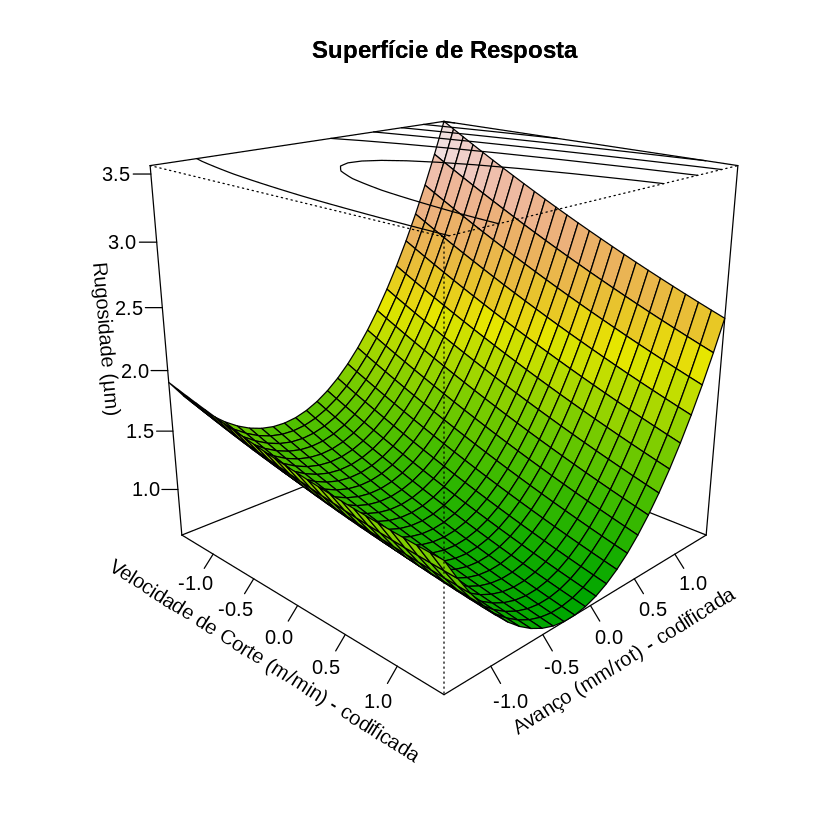

In [47]:
persp(modelo_usinagem,
      ~ x1 + x2,
      col = terrain.colors(50),
      contours = "top",

      xlabs = c("Velocidade de Corte (m/min) - codificada",
                "Avanço (mm/rot) - codificada"),

      zlab = "Rugosidade (µm)",

      theta = 45,
      phi = 20,

      main = "Superfície de Resposta")

Vamos estudar uma nova equação, retirando os termos que não foram significativamente relevantes:

In [49]:
modelo_simplificado <- rsm(Rugosidade ~ FO(x1, x2) + I(x2^2), data = dados_mecanica)
summary(modelo_simplificado)


Call:
rsm(formula = Rugosidade ~ FO(x1, x2) + I(x2^2), data = dados_mecanica)

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept)  0.960870   0.048873 19.6604 1.056e-08 ***
x1          -0.263137   0.047844 -5.4998 0.0003803 ***
x2           0.444454   0.047844  9.2896 6.585e-06 ***
I(x2^2)      0.676087   0.050869 13.2907 3.211e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Multiple R-squared:  0.9702,	Adjusted R-squared:  0.9603 
F-statistic: 97.73 on 3 and 9 DF,  p-value: 3.47e-07

Analysis of Variance Table

Response: Rugosidade
            Df Sum Sq Mean Sq F value    Pr(>F)
FO(x1, x2)   2 2.1342  1.0671  58.272 7.071e-06
I(x2^2)      1 3.2348  3.2348 176.643 3.211e-07
Residuals    9 0.1648  0.0183                  
Lack of fit  5 0.1618  0.0324  43.151  0.001423
Pure error   4 0.0030  0.0007                  

Direction of steepest ascent (at radius 1):
        x1         x2 
-0.5094538  0.8604980 

Corresponding increment in original 

O modelo que dantes poderia ser:

$R_a=0.9400-0.2632V_c+0.4445f+0.6801f^2$,

Foi estimado como:

$R_a=0.9608-0.2631V_c+0.4444f+0.6760f^2$.

Os termos deste modelo já apresenta evidências de significânica em todos os fatores, apesar do _Lack of Fit_ apresentar evidências de que o modelo ainda não é o mais adequado. Outras combinações poderiam ser testadas para não rejeitar a hipótese nula do _Lack of Fit_, ou se observarmos o $R^2$ do modelo anterior com o atual, poderíamos até decidir ficar com ele. Pra efeito didático, vamos procurar o menor valor de rugosidade deste último modelo.

A visualização do gráfico do último modelo pode ser vista por meio do _script_ a seguir:

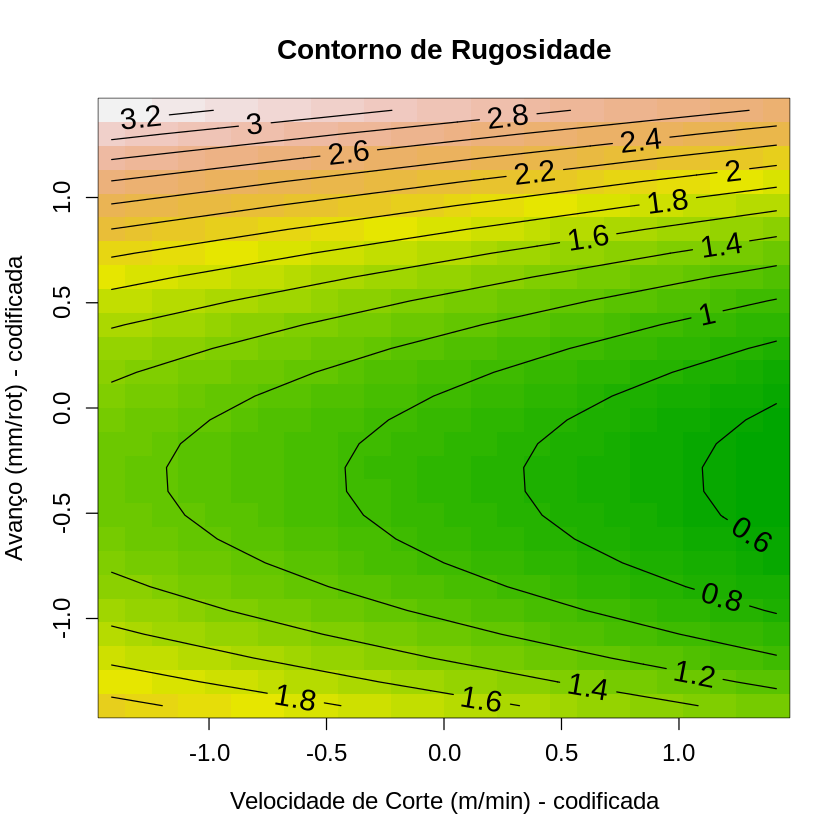

In [50]:
suppressWarnings(contour(modelo_simplificado, ~ x1 + x2,
        image = TRUE,
        xlabs = c("Velocidade de Corte (m/min) - codificada",
                  "Avanço (mm/rot) - codificada"),
        main = "Contorno de Rugosidade",
        labcex = 1.5,
        cex.lab = 1.2,
        cex.main = 1.4,
        cex.axis = 1.2))

# Adicionar os pontos experimentais
points(dados_mecanicaR$x1,
       dados_mecanicaR$x2,
       pch = 19,
       col = "black",
       cex = 1.2)

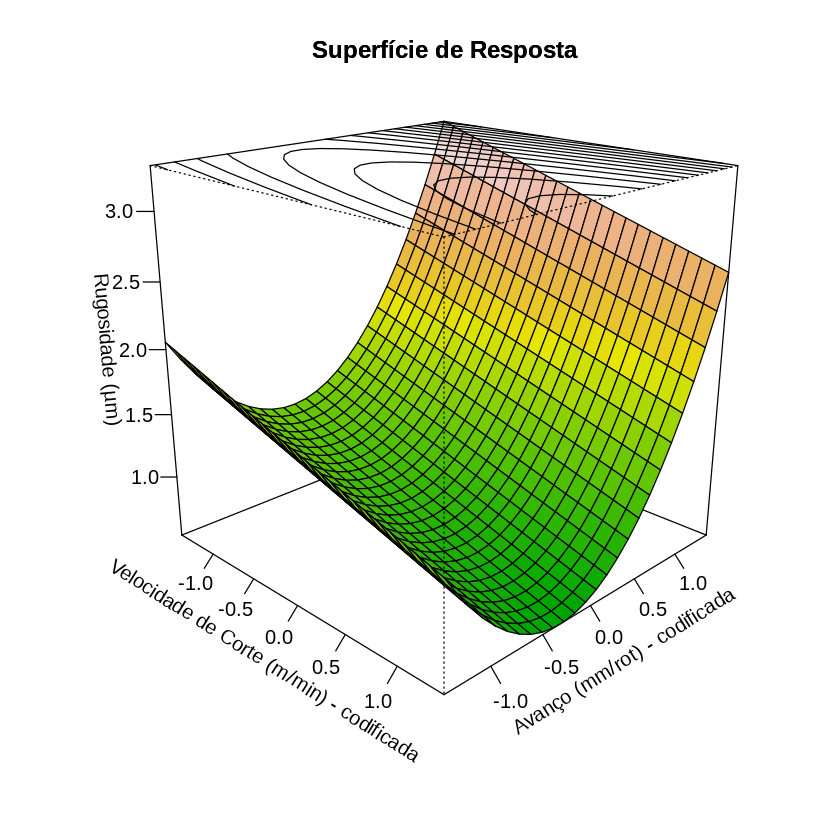

In [51]:
persp(modelo_simplificado,
      ~ x1 + x2,
      col = terrain.colors(50),
      contours = "top",

      xlabs = c("Velocidade de Corte (m/min) - codificada",
                "Avanço (mm/rot) - codificada"),

      zlab = "Rugosidade (µm)",

      theta = 45,
      phi = 20,

      main = "Superfície de Resposta")

## Encontrando um ponto de mínimo em uma região limitada

Verifica-se por meio desses dois gráficos que o menor valor de rugosidade encontra-se entre $V_c^{cod} ≈ 1.5$ e $f^{cod}≈-0.5$.

Por meio do _script_ abaixo nós podemos verificar o ponto de mínimo da rugosidade, dentro desse delineamento:

In [52]:
f <- function(x){
  predict(modelo_simplificado,
          newdata = data.frame(x1 = x[1], x2 = x[2]))
}

otimo <- optim(
  par = c(1.5,-0.5),
  fn = f,
  method = "L-BFGS-B",
  lower = c(-sqrt(2), -sqrt(2)),
  upper = c( sqrt(2),  sqrt(2))
)

otimo

$par
[1]  1.4142136 -0.3286962

$value
[1] 0.5156923

$counts
function gradient 
      10       10 

$convergence
[1] 0

$message
[1] "CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL"

Assim, o algoritmo mostrou que o pontos de mínimo desse intervalor encontra-se em $V_c^{cod} ≈ 1.41$ e $f^{cod}≈-0.32$, onde a rugosidade estimada é de $R_a=0.51$. Veja a localização desse ponto no novo modelo ajustado:

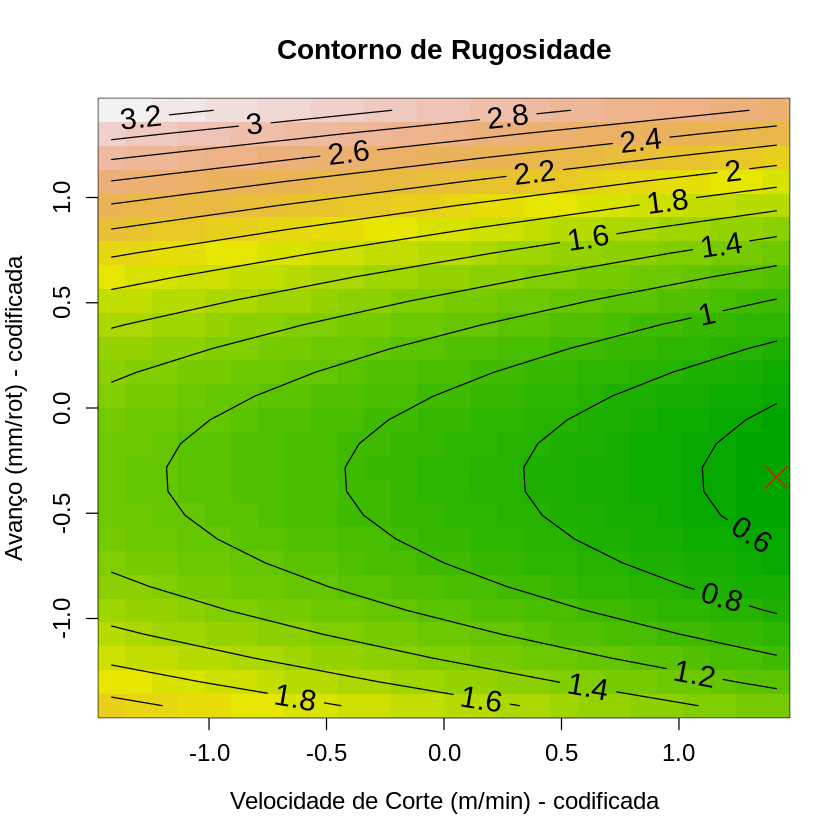

In [53]:
suppressWarnings(contour(modelo_simplificado, ~ x1 + x2,
        image = TRUE,
        xlabs = c("Velocidade de Corte (m/min) - codificada",
                  "Avanço (mm/rot) - codificada"),
        main = "Contorno de Rugosidade",
        labcex = 1.5,
        cex.lab = 1.2,
        cex.main = 1.4,
        cex.axis = 1.2))

# Adicionar os pontos experimentais
points(1.4142135623731,
       -0.328696154051596,
       pch = 4,
       col = "red",
       cex = 2.5)

Os valores reais de velocidade de corte e avanço que representa a menor rugosidade são:

In [54]:
Vc_otimo <- cod2rea(otimo$par[1], 150, 30)
f_otimo  <- cod2rea(otimo$par[2], .15, .05)
rugosidade_min <- otimo$value

cat("\n--- RESULTADOS DO MODELO SIMPLIFICADO ---",
    "\nVelocidade de Corte Ideal (Vc):", round(Vc_otimo, 2), "m/min",
    "\nAvanço Ideal (f):", round(f_otimo, 4), "mm/rot",
    "\nRugosidade Mínima Estimada (Ra):", round(rugosidade_min, 3), "µm\n")


--- RESULTADOS DO MODELO SIMPLIFICADO --- 
Velocidade de Corte Ideal (Vc): 192.43 m/min 
Avanço Ideal (f): 0.1336 mm/rot 
Rugosidade Mínima Estimada (Ra): 0.516 µm
